In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("all_data.csv")

In [2]:
print(df.head())

  Country  Year  Life expectancy at birth (years)           GDP
0   Chile  2000                              77.3  7.786093e+10
1   Chile  2001                              77.3  7.097992e+10
2   Chile  2002                              77.8  6.973681e+10
3   Chile  2003                              77.9  7.564346e+10
4   Chile  2004                              78.0  9.921039e+10


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           96 non-null     object 
 1   Year                              96 non-null     int64  
 2   Life expectancy at birth (years)  96 non-null     float64
 3   GDP                               96 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.1+ KB
None


In [4]:
print(df["Country"].unique())

['Chile' 'China' 'Germany' 'Mexico' 'United States of America' 'Zimbabwe']


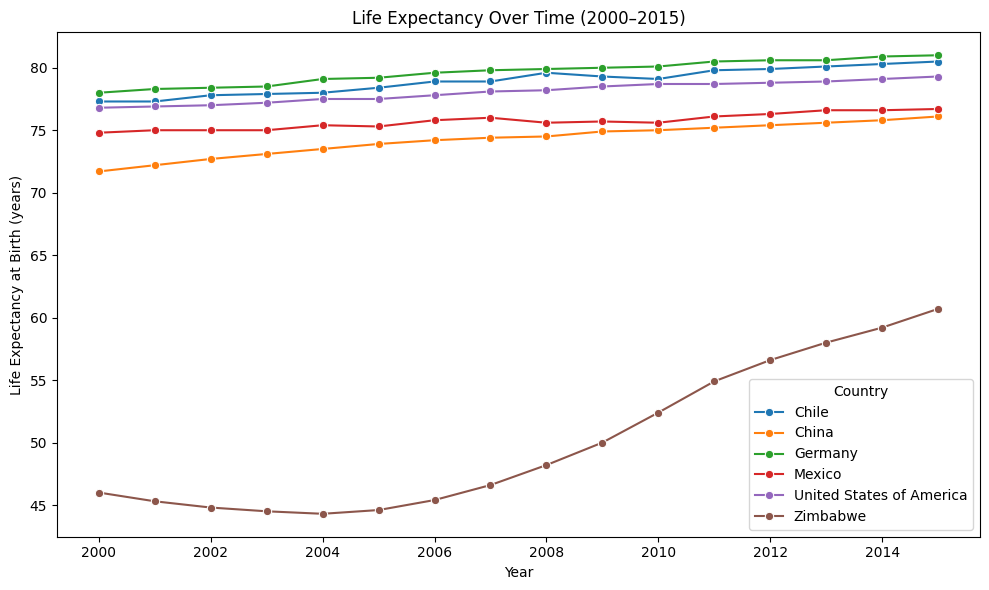

In [5]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="Year",
    y="Life expectancy at birth (years)",
    hue="Country",
    marker="o"
)
plt.title("Life Expectancy Over Time (2000–2015)")
plt.ylabel("Life Expectancy at Birth (years)")
plt.tight_layout()
plt.show()

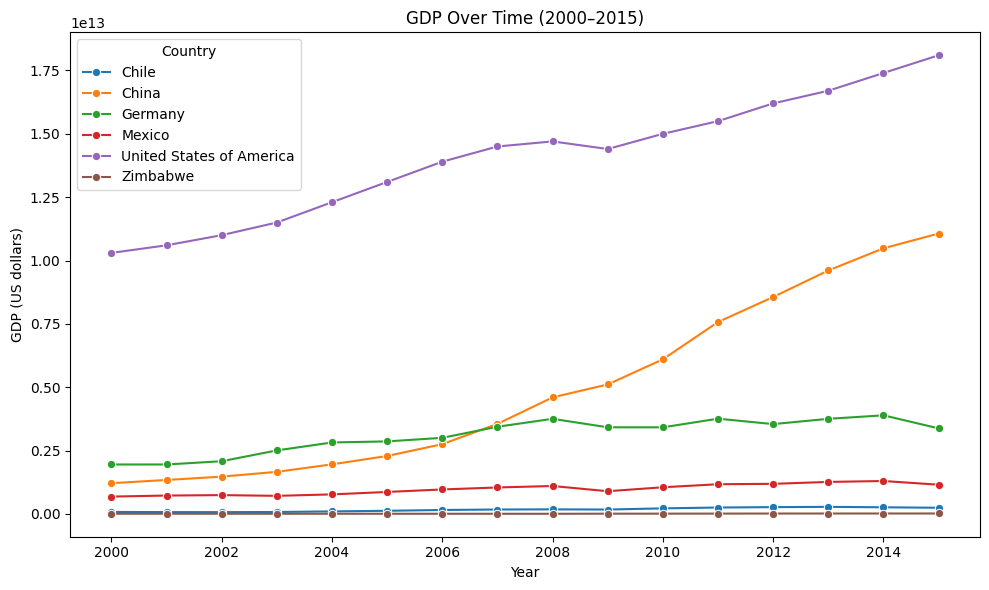

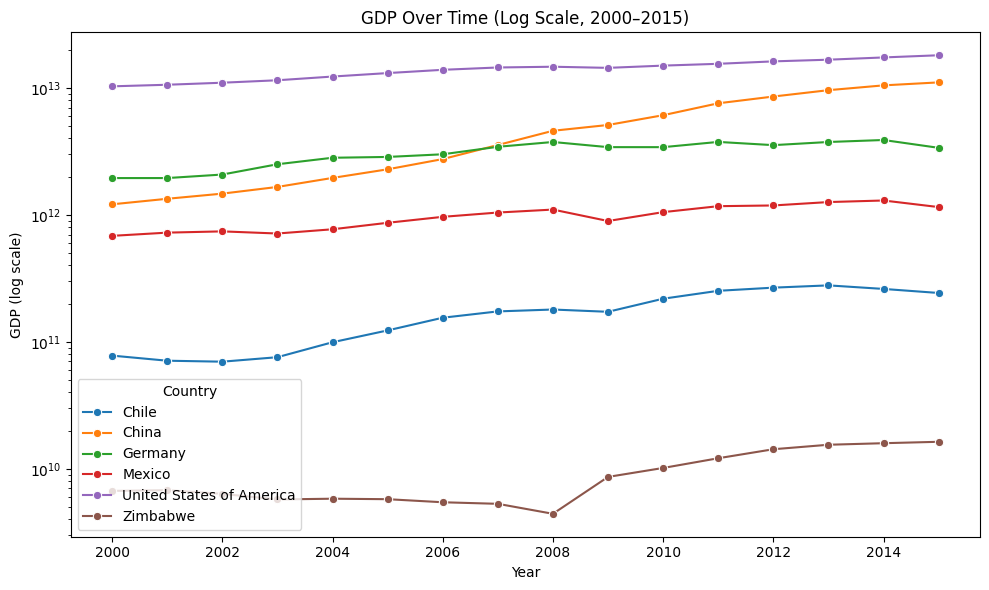

In [8]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="Year",
    y="GDP",
    hue="Country",
    marker="o"
)
plt.title("GDP Over Time (2000–2015)")
plt.ylabel("GDP (US dollars)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="Year",
    y="GDP",
    hue="Country",
    marker="o"
)
plt.yscale("log")
plt.title("GDP Over Time (Log Scale, 2000–2015)")
plt.ylabel("GDP (log scale)")
plt.tight_layout()
plt.show()

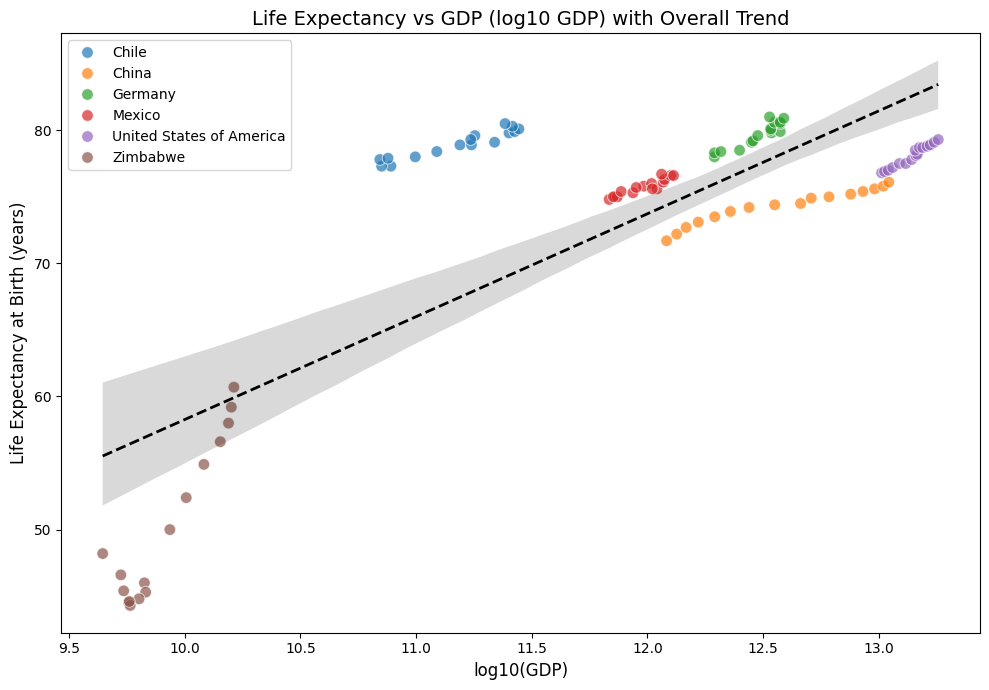

In [15]:
# Create the log-transformed GDP
df["log_GDP"] = np.log10(df["GDP"])

# Create the combined plot
plt.figure(figsize=(10, 7))

# Scatter plot by country
sns.scatterplot(
    data=df,
    x="log_GDP",
    y="Life expectancy at birth (years)",
    hue="Country",
    alpha=0.7,
    s=70
)

# Regression line across all data (no hue, just the trend)
sns.regplot(
    data=df,
    x="log_GDP",
    y="Life expectancy at birth (years)",
    scatter=False,
    color="black",
    line_kws={"linewidth": 2, "linestyle": "--", "label": "Overall Trend"}
)

# Titles and labels
plt.title("Life Expectancy vs GDP (log10 GDP) with Overall Trend", fontsize=14)
plt.xlabel("log10(GDP)", fontsize=12)
plt.ylabel("Life Expectancy at Birth (years)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## Quantitative analysis (correlations)
### Overall correlation

In [21]:
overall_corr = df["Life expectancy at birth (years)"].corr(df["GDP"])
print("Overall correlation:", overall_corr)


Overall correlation: 0.3432067484491559


### Correlation per country

In [19]:
by_country_corr = (
    df.groupby("Country")[["GDP", "Life expectancy at birth (years)"]]
    .apply(lambda g: g["Life expectancy at birth (years)"].corr(g["GDP"]))
)
print(by_country_corr)

Country
Chile                       0.949877
China                       0.908526
Germany                     0.932699
Mexico                      0.932238
United States of America    0.981709
Zimbabwe                    0.966200
dtype: float64


## Comparing countries (summary stats)

Average life expectancy & GDP

In [16]:
summary = df.groupby("Country").agg(
    avg_life=("Life expectancy at birth (years)", "mean"),
    avg_gdp=("GDP", "mean")
).sort_values("avg_life", ascending=False)

print(summary)

                          avg_life       avg_gdp
Country                                         
Germany                   79.65625  3.094776e+12
Chile                     78.94375  1.697888e+11
United States of America  78.06250  1.407500e+13
Mexico                    75.71875  9.766506e+11
China                     74.26250  4.957714e+12
Zimbabwe                  50.09375  9.062580e+09
